### Nottoyer les données

***prendre les données***

In [3]:
import pandas as pd
data = pd.read_excel("c:/Users/Youcode/Desktop/SegmentIQ/data/data.xlsx")

In [4]:
data_clean = data.copy()

In [5]:
print(data.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


***supprimer les rows qui contient les valeurs manquants NaN dans le columns de customers***

In [6]:
def remove_NaN(data):
    return data.dropna(subset=["CustomerID"])

In [7]:
def remove_canclled(data):
    return data[~data["InvoiceNo"].astype(str).str.startswith("C")]


In [8]:
def fix_quantity_prix(data):
    return data[
        (data["Quantity"] > 0) &
        (data["UnitPrice"] > 0)
    ]

In [9]:
def rfm(data):
    data["Revenue"] = data["Quantity"] * data["UnitPrice"]
    data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
    date_reference = data["InvoiceDate"].max()
    rfm = data.groupby("CustomerID").agg(
        Recency=("InvoiceDate", lambda x: (date_reference - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    ).reset_index()
    return rfm

In [10]:
data_clean = remove_NaN(data_clean)
data_clean = remove_canclled(data_clean)
data_clean = fix_quantity_prix(data_clean)
data_clean = rfm(data_clean)
display(data_clean.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [11]:
print(data_clean.describe())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    91.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     0.000000     1.000000       3.750000
25%    13813.250000    17.000000     1.000000     307.415000
50%    15299.500000    50.000000     2.000000     674.485000
75%    16778.750000   141.000000     5.000000    1661.740000
max    18287.000000   373.000000   209.000000  280206.020000


In [12]:
import numpy as np
data_clean["Recency"] = np.log1p(data_clean["Recency"])
data_clean["Frequency"] = np.log1p(data_clean["Frequency"])
data_clean["Monetary"] = np.log1p(data_clean["Monetary"])

In [13]:
from sklearn.preprocessing import StandardScaler
columns = ["Recency","Frequency","Monetary"]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean[columns])
print(data_scaled)

[[ 1.40989446 -0.95521426  3.70622476]
 [-2.14649825  1.07442519  1.41184341]
 [ 0.38397128  0.38630445  0.7164889 ]
 ...
 [-1.17860486 -0.36158278 -1.11812113]
 [-1.66255156  2.17800394  0.83829669]
 [-0.00442205  0.05960547  0.73400231]]


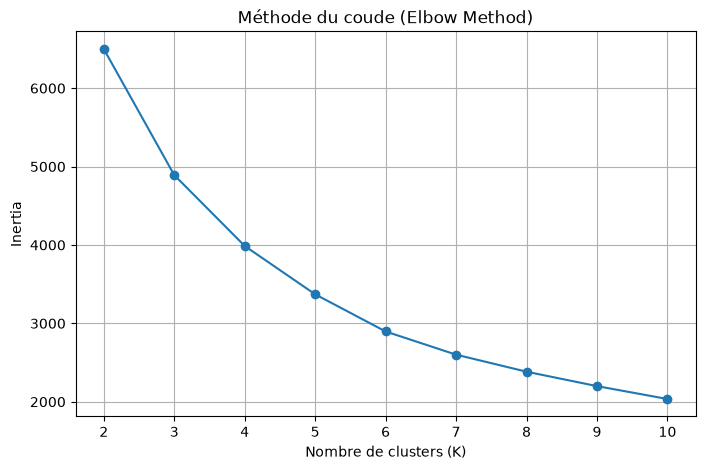

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertias = []
K_values = range(2,11)
for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(data_scaled)
    inertias.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.title("Méthode du coude (Elbow Method)")
plt.xticks(K_values)
plt.grid(True)
plt.show()

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
K_values = [2, 4]
for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f"K = {k} | Silhouette Score = {score:.4f}")

K = 2 | Silhouette Score = 0.4345
K = 4 | Silhouette Score = 0.3355


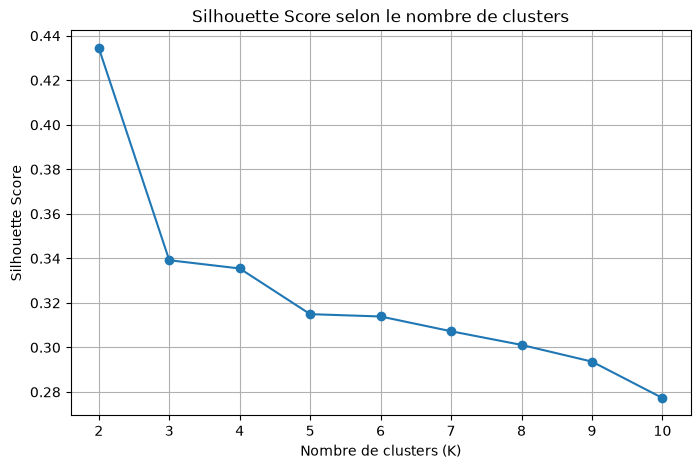

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
K_values = range(2, 11)
silhouette_scores = []
for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(K_values, silhouette_scores, marker="o")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score selon le nombre de clusters")
plt.xticks(list(K_values))
plt.grid(True)
plt.show()

### Justification du choix de K = 3

Différentes valeurs de K ont été testées avec la méthode du coude (Elbow) et le Silhouette Score pour observer la structure naturelle des données.

Cependant, **le cahier des charges impose exactement 3 segments** (contrainte métier). Le modèle final est donc entraîné avec `K = 3` pour répondre spécifiquement à ce besoin métier, même si l'analyse algorithmique pouvait suggérer une autre valeur optimale.

In [17]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(data_scaled)
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.26658858  0.15291726  0.28116685]
 [-1.23332603  1.65707928  1.40160218]
 [ 0.70734719 -0.7689227  -0.78459096]]


In [18]:
data_rfm = data_clean.copy()
data_rfm["Cluster"] = clusters
data_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,5.786897,0.693147,11.253955,0
1,12347.0,0.693147,2.079442,8.368925,1
2,12348.0,4.317488,1.609438,7.494564,0
3,12349.0,2.944439,0.693147,7.472245,0
4,12350.0,5.736572,0.693147,5.815324,2


In [19]:
data_rfm["Cluster"].value_counts().sort_index()

Cluster
0    1687
1     731
2    1920
Name: count, dtype: int64

In [ ]:
profiling = data_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
display(profiling)

### Interprétation métier des 3 clusters

En analysant les moyennes des variables RFM pour chaque cluster, nous pouvons attribuer les profils métiers suivants :

- **Clients Inactifs** : Ce segment présente une **Récence élevée** (dernier achat très ancien), avec une **Fréquence** et un **Montant faibles**. Ils ont une très faible valeur business actuelle.
- **Clients Premium** : Ce segment se distingue par une **Récence très faible** (achats très récents), une **Fréquence très élevée** et un **Montant très élevé**. Ce sont les meilleurs clients, à très forte valeur ajoutée pour l'entreprise.
- **Clients Réguliers** : Ce segment montre des valeurs intermédiaires pour les trois indicateurs. Ils achètent de manière régulière mais avec des montants et des fréquences modérés. Ils constituent la base solide du chiffre d'affaires.

In [20]:
transactions_clean = data.copy()
transactions_clean = remove_NaN(transactions_clean)
transactions_clean = remove_canclled(transactions_clean)
transactions_clean = fix_quantity_prix(transactions_clean)
transactions_clean["InvoiceDate"] = pd.to_datetime(
    transactions_clean["InvoiceDate"]
)
transactions_clean["Revenue"] = (
    transactions_clean["Quantity"] *
    transactions_clean["UnitPrice"]
)
date_reference = transactions_clean["InvoiceDate"].max()
rfm_original = transactions_clean.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (date_reference - x.max()).days
    ),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()
cluster_labels = data_rfm[
    ["CustomerID", "Cluster"]
].copy()
rfm_profile = rfm_original.merge(
    cluster_labels,
    on="CustomerID",
    how="inner",
    validate="one_to_one"
)
profiling_original = rfm_profile.groupby("Cluster").agg(
    Nombre_clients=("CustomerID", "nunique"),
    Recence_moyenne=("Recency", "mean"),
    Frequence_moyenne=("Frequency", "mean"),
    Montant_moyen=("Monetary", "mean"),
    Chiffre_affaires=("Monetary", "sum")
).reset_index()
profiling_original["Contribution_CA_%"] = (
    profiling_original["Chiffre_affaires"]
    / profiling_original["Chiffre_affaires"].sum()
    * 100
)
profiling_original = profiling_original.round(2)
display(profiling_original)

,Cluster,Nombre_clients,Recence_moyenne,Frequence_moyenne,Montant_moyen,Chiffre_affaires,Contribution_CA_%
0,0,1687,46.36,3.55,1405.56,2371178.83,26.61
1,1,731,12.94,13.65,8018.89,5861807.93,65.78
2,2,1920,161.16,1.34,353.34,678421.14,7.61


In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())
print(X_pca)

[0.75113199 0.18759456]
0.9387265556507939
[[ 0.89797002  2.65158897]
 [ 2.60546464 -0.89433168]
 [ 0.4694092   0.75584331]
 ...
 [-0.28667362 -1.6087403 ]
 [ 2.69757158 -0.45964154]
 [ 0.47687176  0.34903209]]


Visualisation des clusters avec PCA (ACP)

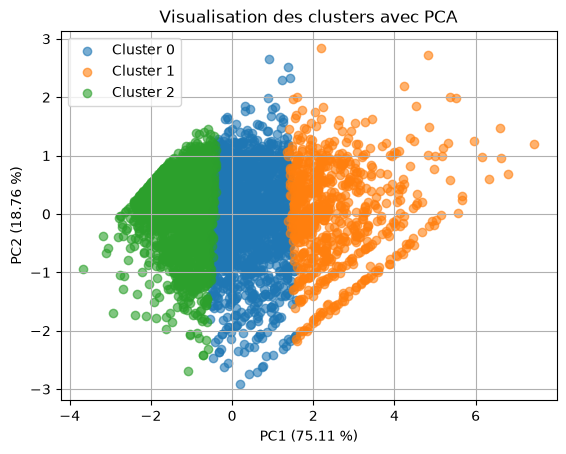

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = data_rfm["Cluster"].to_numpy()
for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )
plt.xlabel("PC1 (75.11 %)")
plt.ylabel("PC2 (18.76 %)")
plt.title("Visualisation des clusters avec PCA")
plt.legend()
plt.grid(True)
plt.show()

### Analyse de la visualisation PCA

La PCA nous permet de projeter nos données de 3 dimensions (Recency, Frequency, Monetary) vers 2 dimensions pour la visualisation.

Sur le graphique ci-dessus, nous pouvons observer la séparation des clusters. S'il existe un chevauchement entre certains segments, c'est normal : la réduction de dimension entraîne toujours une perte d'information. Les clusters ont été formés dans l'espace 3D original (où ils sont mieux séparés), et la PCA **n'est utilisée ici qu'à des fins de visualisation**, et non pour entraîner le K-Means.

In [23]:
X = data_rfm[["Recency", "Frequency", "Monetary"]]
noms_clusters = {
    0: "Clients Réguliers",
    1: "Clients Premium",
    2: "Clients Inactifs"
}
data_rfm["Nom_Cluster"] = data_rfm["Cluster"].map(noms_clusters)
y = data_rfm["Nom_Cluster"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib
import os
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Entrainement termine")
os.makedirs("../models" , exist_ok=True)
model_data = {
    "model": rf_model,
    "noms_clusters": noms_clusters
}
joblib.dump(model_data, "../models/rf_cluster_model.joblib")
import pandas as pd
import joblib
model_data = joblib.load("../models/rf_cluster_model.joblib")
model = model_data["model"]
noms_clusters = model_data["noms_clusters"]
new_data = pd.DataFrame({
    "Recency": [3.5],
    "Frequency": [1.1],
    "Monetary": [6.5]
})
prediction = model.predict(new_data)[0]
print("Données du client :")
display(new_data)
print("Cluster :", prediction)


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Scores validation croisée :", cv_scores)
print("Accuracy moyenne CV :", cv_scores.mean())
print("Écart-type CV :", cv_scores.std())

### Validation croisée (Cross-Validation)

Nous appliquons une **validation croisée à 5 folds (`cv=5`) uniquement sur les données d'entraînement (`X_train`, `y_train`)**. 
Cela permet de vérifier la robustesse et la stabilité du Random Forest sur plusieurs sous-échantillons d'entraînement, sans jamais toucher au jeu de test (`X_test`), qui reste totalement indépendant pour l'évaluation finale.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :")
print(cm)
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Clients Inactifs",
        "Clients Premium",
        "Clients Réguliers"
    ]
))

### Interprétation des métriques

Les métriques (Accuracy, Precision, Recall, F1-score) et la matrice de confusion montrent les performances de notre modèle.

**Attention :** Ici, le modèle de classification (Random Forest) apprend à reproduire les classes générées synthétiquement par notre algorithme de clustering (K-Means). Une accuracy très élevée signifie que le Random Forest arrive parfaitement à recréer les frontières de décision du K-Means à partir des variables RFM. Ce n'est pas une vérité métier indépendante, mais la capacité du modèle à généraliser notre propre segmentation sur de nouveaux clients.

### Importance des variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
display(feature_importance)
plt.figure(figsize=(8, 4))
plt.bar(feature_importance["Feature"], feature_importance["Importance"], color='skyblue')
plt.title("Importance des variables dans le Random Forest")
plt.ylabel("Importance")
plt.show()

Cette analyse nous indique quel indicateur RFM (Recency, Frequency ou Monetary) pèse le plus dans la décision du Random Forest pour attribuer un cluster. La variable la plus importante est celle qui sépare le mieux nos 3 segments métier.

### Prédiction pour un nouveau client

In [ ]:
import numpy as np
nouveau_client_rfm = pd.DataFrame({
    "Recency": [15],      
    "Frequency": [10],    
    "Monetary": [500.0]   
})
nouveau_client_transforme = np.log1p(nouveau_client_rfm)
cluster_predit = rf_model.predict(nouveau_client_transforme)[0]
noms_clusters_mapping = {0: "Clients Inactifs", 1: "Clients Premium", 2: "Clients Réguliers"}
nom_segment = noms_clusters_mapping.get(cluster_predit, f"Cluster {cluster_predit}")
print("--- NOUVEAU CLIENT ---")
print(nouveau_client_rfm)
print(f"\nCluster prédit : {cluster_predit}")
print(f"Segment métier : {nom_segment}")

### Sauvegarde et rechargement du modèle

In [ ]:
import joblib
model_path = "random_forest_rfm.joblib"
joblib.dump(rf_model, model_path)
print(f"Modèle sauvegardé sous : {model_path}")
modele_charge = joblib.load(model_path)
cluster_test = modele_charge.predict(nouveau_client_transforme)[0]
print(f"Prédiction avec le modèle rechargé : Cluster {cluster_test}")

### Application Streamlit

L'application Streamlit permettant de mettre en production ce modèle et d'interagir avec via une interface web (saisie des informations RFM, prédiction du segment) a été développée dans le fichier `app.py` situé à la racine du projet.

Pour la lancer, exécutez la commande suivante dans votre terminal :
```bash
streamlit run app.py
```